In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

d_max = 40.0
depth_path = "/ssd1/jm_data/depth/ssl/depth-hints/glass_hints/2025_03_23/2025_03_23_drive_0002_sync/image_02/0000001274.npy"
# depth = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE) / 255.0 * d_max
depth = np.load(depth_path)
# print(np.unique(depth))
col, row = 320, 160
print(depth[row, col])
K = np.array([[263.9025, 0, 323.5725],
            [0, 263.675, 179.957],
            [0, 0, 1]
            ], dtype=np.float32)

def to_3d(depth, K, col, row):
    K_inv = np.linalg.inv(K)
    p_homo = np.array([col, row, 1.0])
    # print(depth.shape, K_inv.shape, p_homo.shape)
    P = depth[row, col] * K_inv @ p_homo
    return P



3.495067


In [3]:
# 8 neighbors convention

def compute_neighbors(depth, row, col):
    H, W = depth.shape
    x = 1
    pairs = [((col+x, row), (col, row-x)),
              ((col+x, row-x), (col-x, row-x)),
              ((col-x, row), (col, row+x)),
              ((col+x, row+x), (col-x, row+x))
             ]
    return pairs

pairs = compute_neighbors(depth, row, col)


In [4]:
# Calculate Ps on all pairs

P_pairs = []
for pair in pairs:
    P_pair = []
    for coord in pair:
        col, row = coord
        P = to_3d(depth, K, col, row)
        print(f"P of {coord}: {P}")
        P_pair.append(P)
    P_pairs.append(P_pair) 

print(P_pairs)

P of (321, 160): [-0.03407009 -0.26453424  3.49506688]
P of (320, 159): [-0.04731387 -0.27778944  3.49506688]
P of (321, 159): [-0.03407009 -0.27778944  3.49506688]
P of (319, 159): [-0.06055765 -0.27778944  3.49506688]
P of (319, 160): [-0.06055765 -0.26453424  3.49506688]
P of (320, 161): [-0.04731387 -0.25127903  3.49506688]
P of (321, 161): [-0.03407009 -0.25127903  3.49506688]
P of (319, 161): [-0.06055765 -0.25127903  3.49506688]
[[array([-0.03407009, -0.26453424,  3.49506688]), array([-0.04731387, -0.27778944,  3.49506688])], [array([-0.03407009, -0.27778944,  3.49506688]), array([-0.06055765, -0.27778944,  3.49506688])], [array([-0.06055765, -0.26453424,  3.49506688]), array([-0.04731387, -0.25127903,  3.49506688])], [array([-0.03407009, -0.25127903,  3.49506688]), array([-0.06055765, -0.25127903,  3.49506688])]]


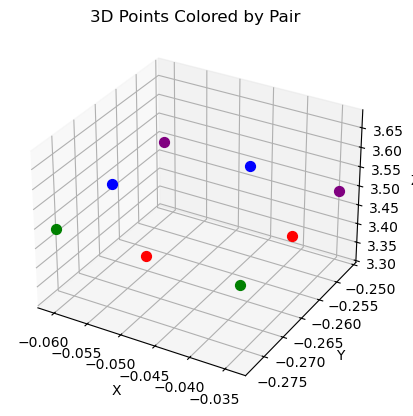

In [5]:
# 점군들 시각화

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

colors = ['red', 'green', 'blue', 'purple']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i, (p1, p2) in enumerate(P_pairs):
    color = colors[i % len(colors)]
    ax.scatter(p1[0], p1[1], p1[2], color=color, s=50, label=f'pair {i+1}' if i == 0 else "")
    ax.scatter(p2[0], p2[1], p2[2], color=color, s=50)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Points Colored by Pair")

plt.show()

center : [-0.04731387 -0.26453424  3.49506688]
[ 0.          0.         -0.99994304]
[ 0.         -0.         -0.99997152]
[ 0.          0.         -0.99994304]
[ 0.         -0.          0.99997152]


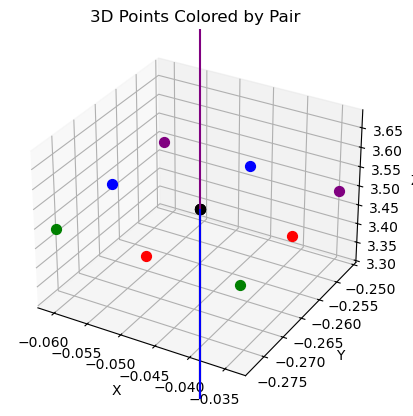

In [6]:
# normal 벡터 구하기

def compute_normal(center, p1, p2):
    v1 = p1 - center
    v2 = p2 - center
    normal = np.cross(v1, v2)
    return normal / (np.linalg.norm(normal) + 1e-8)

col, row = 320, 160

colors = ['red', 'green', 'blue', 'purple']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

center = to_3d(depth, K, col, row)
print(f"center : {center}")
normals = []
for i, (p1, p2) in enumerate(P_pairs):
    color = colors[i % len(colors)]
    normal = compute_normal(center, p1, p2)
    print(normal)
    ax.scatter(p1[0], p1[1], p1[2], color=color, s=50, label=f'pair {i+1}' if i == 0 else "")
    ax.scatter(p2[0], p2[1], p2[2], color=color, s=50)
    ax.scatter(center[0], center[1], center[2], color='black', s=50)
    plt.quiver(center[0], center[1], center[2], normal[0], normal[1], normal[2], length=1.0, normalize=True, color=color)
    normals.append(normal)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Points Colored by Pair")

plt.show()



[-0.04731387 -0.26453424  3.49506688]
[ 0.          0.         -0.99999998]


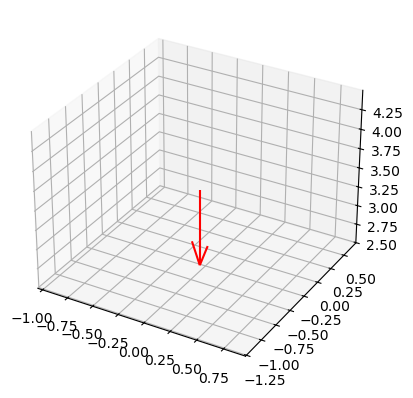

In [7]:
# Final normal 
n_avg = np.mean(normals, axis=0)
n_final = n_avg / (np.linalg.norm(n_avg) + 1e-8)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

center = to_3d(depth, K, col, row)
print(center)
print(n_final)

plt.quiver(center[0], center[1], center[2], n_final[0], n_final[1], n_final[2], length=1.0, normalize=True, color="red")
ax.set_xlim([center[0]-1, center[0]+1])
ax.set_ylim([center[1]-1, center[1]+1])
ax.set_zlim([center[2]-1, center[2]+1])

plt.show()


In [8]:
## Generate ground mask

# set ideal ground normal
i_norm = [0.0, 1.0, 0.0]

# set across cosine similarity
def cosine_sim(v1, v2):
    dot = np.dot(v1, v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    return dot / (norm1 * norm2 + 1e-8)

def angle_between(v1, v2):
    cos_sim = cosine_sim(v1, v2)
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    angle_rad = np.arccos(cos_sim)
    angle_deg = np.degrees(angle_rad)
    return angle_deg

similarity = cosine_sim(i_norm, n_final)
angle = angle_between(i_norm, n_final)
print(f"similarity : {similarity:.4f}")
print(f"Angle difference : {angle:.2f} degrees")
S_max = 15.0

if angle < S_max:
    ground = True
else:
    ground = False

print(ground)

similarity : 0.0000
Angle difference : 90.00 degrees
False


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.999998464468976..0.999999793193033].


cam points : (352, 640, 3)
scale factor: 1.1015421408145796
relative depth : 
[ 1.0164405  1.0173682  1.019281  ... 16.669611  16.702192  16.7256   ]
recovered depth : 
[ 1.0164405  1.0173682  1.019281  ... 16.669611  16.702192  16.7256   ]


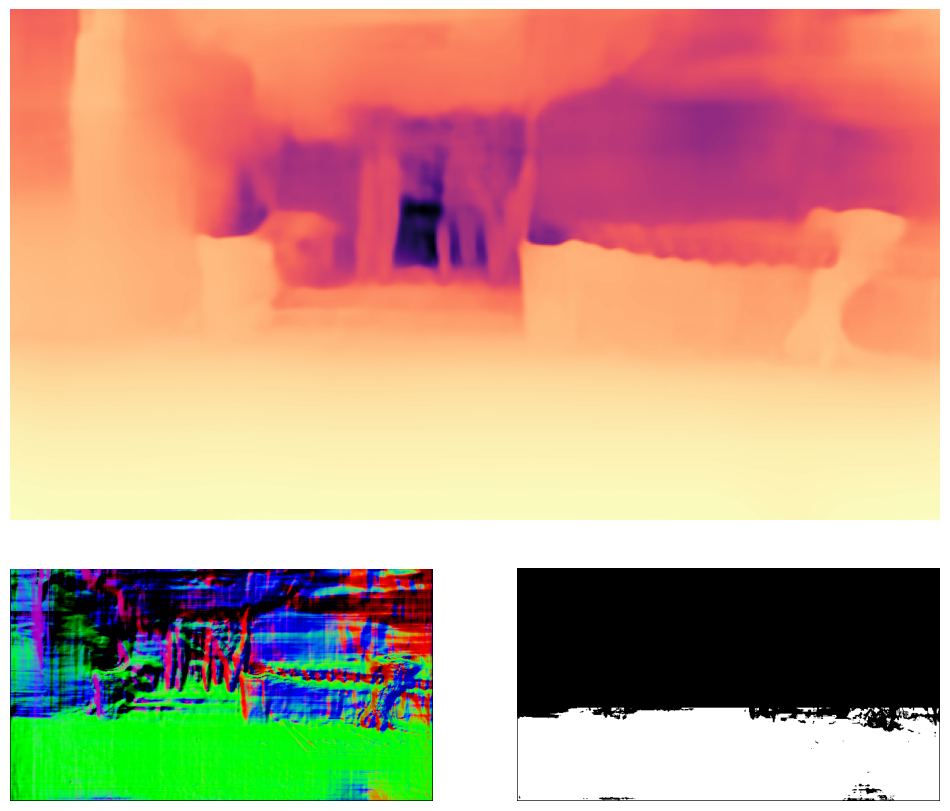

In [36]:
## Test for all points
K = np.array([[263.9025, 0, 323.5725],
            [0, 263.675, 179.957],
            [0, 0, 1]
            ], dtype=np.float32)
# w, h = 1242, 375
# K = np.array([[0.58 * w, 0, 0.5 * w],
#             [0, 1.92* h, 0.5 * h],
#             [0, 0, 1]
#             ], dtype=np.float32)

        # zed2i
def backproject_depth_numpy(depth, inv_K):
    """
    depth: (H, W) numpy array
    inv_K: (3, 3) numpy array, inverse of camera intrinsic matrix

    returns: (H, W, 3) numpy array of 3D points
    """
    H, W = depth.shape

    # (1) 픽셀 좌표 생성 (u, v)
    u, v = np.meshgrid(np.arange(W), np.arange(H), indexing='xy')
    ones = np.ones_like(u)

    # (2) homogeneous 2D pixel coordinates: shape (3, H*W)
    pix_coords = np.stack([u, v, ones], axis=0).reshape(3, -1)

    # (3) backproject: 3D direction vectors (before scaling by depth)
    cam_dirs = inv_K @ pix_coords  # shape (3, H*W)

    # (4) depth map → 1D
    depth_flat = depth.reshape(-1)  # shape: (H*W,)

    # (5) scale the direction vectors
    cam_points = cam_dirs * depth_flat  # broadcasting → shape (3, H*W)

    # (6) reshape back to (H, W, 3)
    cam_points = cam_points.T.reshape(H, W, 3)

    return cam_points

def normalize_vector(v, eps=1e-8):
    norm = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (norm + eps)

def get_surface_normal_numpy(cam_points, nei=1):
    """
    cam_points: (H, W, 3) numpy array
    return: surface normal map (H, W, 3)
    """
    H, W, _ = cam_points.shape
    pad = nei

    # 중심점 기준 유효 영역
    ctr = cam_points[pad:-pad, pad:-pad]

    x0 = cam_points[pad:-pad, 0:-(2*pad)]
    x1 = cam_points[pad:-pad, 2*pad:]
    y0 = cam_points[0:-(2*pad), pad:-pad]
    y1 = cam_points[2*pad:, pad:-pad]

    x0y0 = cam_points[0:-(2*pad), 0:-(2*pad)]
    x0y1 = cam_points[2*pad:, 0:-(2*pad)]
    x1y0 = cam_points[0:-(2*pad), 2*pad:]
    x1y1 = cam_points[2*pad:, 2*pad:]

    # 벡터 계산
    v_x0 = x0 - ctr
    v_x1 = x1 - ctr
    v_y0 = y0 - ctr
    v_y1 = y1 - ctr

    v_x0y0 = x0y0 - ctr
    v_x0y1 = x0y1 - ctr
    v_x1y0 = x1y0 - ctr
    v_x1y1 = x1y1 - ctr

    # normal 계산 (cross product + normalize)
    n0 = normalize_vector(np.cross(v_x0, v_y0))
    n1 = normalize_vector(np.cross(v_x1, v_y1))
    n2 = normalize_vector(np.cross(v_x0y0, v_x0y1))
    n3 = normalize_vector(np.cross(v_x1y0, v_x1y1))

    normals = normalize_vector((n0 + n1 + n2 + n3) / 4.0)

    # 패딩으로 원래 크기로 복원 (edge는 0으로)
    normal_map = np.zeros_like(cam_points)
    normal_map[pad:-pad, pad:-pad] = normals

    return normal_map

def get_ground_mask_numpy(cam_points, normal_map, threshold_deg=55):
    """
    cam_points: (H, W, 3)
    normal_map: (H, W, 3)
    return: ground_mask (H, W) bool
    """
    H, W = cam_points.shape[:2]

    # 이상적인 ground normal
    ideal = np.array([0.0, 1.0, 0.0])

    # Normalize normal_map
    norm = np.linalg.norm(normal_map, axis=-1, keepdims=True) + 1e-6
    normal_map_normed = normal_map / norm

    # Cosine similarity with vertical
    cos_sim = np.dot(normal_map_normed, ideal)  # (H, W)
    threshold = np.cos(np.radians(threshold_deg))
    vertical_mask = (cos_sim > threshold)

    # Y 좌표 (camera 기준 height)
    y_coords = cam_points[..., 1]
    mask_y = y_coords > -0.3  # 바닥은 음수이고, 너무 가까운 것 제외

    # 이미지 하단 40%만
    row_indices = np.arange(H)
    v_mask = row_indices[:, None] >= int(H * 0.6)  # (H, 1) → broadcast to (H, W)

    v_mask = np.broadcast_to(v_mask, (H, W))  # shape 맞춤

    # 최종 ground mask
    ground_mask = vertical_mask & mask_y & v_mask

    return ground_mask


depth_path = "/ssd1/jm_data/depth/ssl/depth-hints/depth_vis/video/2025_02_28_drive_0002_sync/image_03/0000002405.npy"
# depth = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE) / 255.0 * d_max
depth = np.load(depth_path)
K_inv = np.linalg.inv(K)
cam_points = backproject_depth_numpy(depth.copy(), inv_K=K_inv)
surface_normal = get_surface_normal_numpy(cam_points)
ground_mask = get_ground_mask_numpy(cam_points, surface_normal)

print(f"cam points : {cam_points.shape}")
heights = np.abs(np.sum(cam_points * surface_normal, axis=-1))
cam_heights_masked = heights[ground_mask]
cam_height = np.median(cam_heights_masked)
real_cam_height = 0.8
scale = real_cam_height / cam_height
print(f"scale factor: {scale}")
final_depth = depth
print(f"relative depth : \n{np.unique(depth)}")
print(f"recovered depth : \n{np.unique(final_depth)}")

plt.figure(figsize=(12, 20))
plt.subplot(1,2,1)
plt.imshow(surface_normal)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(ground_mask, cmap='gray')
plt.axis('off')
plt.subplot(2,1,1)
plt.imshow(depth, cmap="magma_r")
plt.axis('off')
plt.show()

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def backproject_depth_torch(depth, inv_K):
    B, _, H, W = depth.shape
    device = depth.device

    u = torch.arange(0, W, device=device)
    v = torch.arange(0, H, device=device)
    grid_u, grid_v = torch.meshgrid(u, v, indexing='xy')

    ones = torch.ones_like(grid_u)
    pix_coords = torch.stack([grid_u, grid_v, ones], dim=0).float()  # (3, H, W)
    pix_coords = pix_coords.reshape(3, -1).unsqueeze(0).repeat(B, 1, 1)  # (B, 3, H*W)

    cam_dirs = torch.bmm(inv_K, pix_coords)  # (B, 3, H*W)
    depth_flat = depth.view(B, 1, -1)

    cam_points = cam_dirs * depth_flat  # (B, 3, H*W)
    cam_points = cam_points.view(B, 3, H, W)
    return cam_points

def get_stereo_M_t2s_torch(baseline=0.12, device='cpu'):
    M = torch.eye(4, device=device).unsqueeze(0)
    M[:, 0, 3] = -baseline
    return M

def reproject_to_source_torch(cam_points, K, M_t2s):
    B, _, H, W = cam_points.shape
    device = cam_points.device

    cam_points_flat = cam_points.view(B, 3, -1)  # (B, 3, H*W)
    ones = torch.ones((B, 1, H * W), device=device)
    cam_points_homo = torch.cat([cam_points_flat, ones], dim=1)  # (B, 4, H*W)

    cam_points_src = torch.bmm(M_t2s, cam_points_homo)[:, :3, :]  # (B, 3, H*W)

    pixels = torch.bmm(K, cam_points_src)  # (B, 3, H*W)
    p0 = pixels[:, :2, :] / (pixels[:, 2:3, :] + 1e-8)  # (B, 2, H*W)
    p0 = p0.view(B, 2, H, W).permute(0, 2, 3, 1)  # (B, H, W, 2)
    return p0

def warp_depth_to_source_view(depth, K, inv_K, M_t2s):
    cam_points = backproject_depth_torch(depth, inv_K)
    p0 = reproject_to_source_torch(cam_points, K, M_t2s)

    B, _, H, W = depth.shape
    p0_norm = p0.clone()
    p0_norm[..., 0] = (p0[..., 0] / (W - 1)) * 2 - 1
    p0_norm[..., 1] = (p0[..., 1] / (H - 1)) * 2 - 1

    depth_warped = F.grid_sample(depth, p0_norm, mode='bilinear', align_corners=True)
    return depth_warped, cam_points, p0

tensor([1.1921e-07, 1.9073e-06, 2.3842e-06,  ..., 8.5993e+00, 8.6577e+00,
        8.6967e+00])


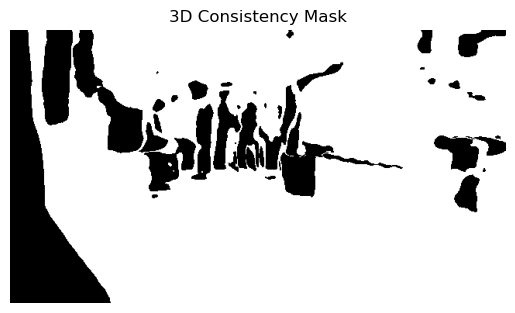

In [38]:
# 3d consistency 확인
import torch
depth_tensor = torch.from_numpy(final_depth).unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)

H, W = depth_tensor.shape[-2:]
# Intrinsics
K = np.array([[263.9025, 0, 323.5725],
            [0, 263.675, 179.957],
            [0, 0, 1]
            ], dtype=np.float32)

# zed2i

K_tensor = torch.from_numpy(K).unsqueeze(0).float()
inv_K_tensor = torch.inverse(K_tensor)

# 1. stereo 변환 행렬
M_t2s = get_stereo_M_t2s_torch(baseline=0.54, device=depth_tensor.device)
M_s2t = torch.inverse(M_t2s)

# 2. target → source로 depth warp
depth_warped_to_src, cam_points, p0 = warp_depth_to_source_view(depth_tensor, K_tensor, inv_K_tensor, M_t2s)

# 3. warped depth → source 3D 복원
cam_points_src = backproject_depth_torch(depth_warped_to_src, inv_K_tensor)

# 4. 다시 target 좌표계로 변환
cam_points_src_flat = cam_points_src.view(1, 3, -1)
ones = torch.ones((1, 1, H * W), device=depth_tensor.device)
cam_points_src_homo = torch.cat([cam_points_src_flat, ones], dim=1)
cam_points_src_to_target = torch.bmm(M_s2t, cam_points_src_homo)[:, :3, :].view(1, 3, H, W)

# 5. z difference 계산
z_diff = torch.abs(cam_points[0, 2] - cam_points_src_to_target[0, 2])
print(torch.unique(z_diff))
mask = (z_diff < 1).float()

# 시각화
plt.imshow(mask.cpu(), cmap='gray')
plt.title("3D Consistency Mask")
# plt.colorbar()
plt.axis("off")
plt.show()

[0.0 0.9880964159965515 0.9970119595527649 ... 6.320982933044434
 6.321586608886719 6.339968681335449]
[ 0.         1.0515127  1.0528848 ... 16.644575  16.667948  16.692652 ]
RMSE : 4.54384362078978


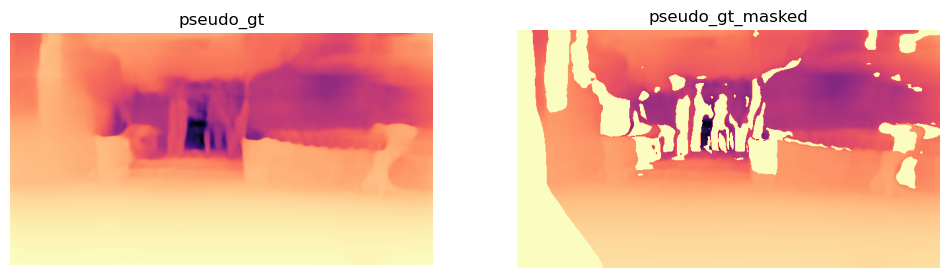

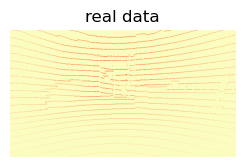

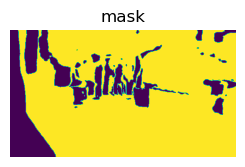

In [ ]:
pseudo_gt = final_depth.copy()
# print(mask.cpu().numpy().shape)
# print(pseudo_gt.shape)
mask_resize = cv2.resize(mask.cpu().numpy(), (640, 360)).astype("bool")
# mask_numpy = mask_resize.cpu().numpy().astype("bool")
real_data = np.load("/ssd1/jm_data/depth/ssl/depth-hints/splits/jbnu_stereo/gt_depths.npz", allow_pickle=True)
real_gt = real_data['data'][-1]
pseudo_gt = cv2.resize(pseudo_gt, (640, 360))
pseudo_gt[~mask_resize] = 0
eval_mask = real_gt > 0
print(np.unique(real_gt))
print(np.unique(pseudo_gt))

err = np.abs(pseudo_gt - real_gt)
# err = err[mask_resize & (real_gt > 0)]
print(f"RMSE : {np.sqrt(np.mean(err**2))}")

plt.figure(figsize=(12, 6))
plt.subplot(1,2,2)
plt.imshow(pseudo_gt, cmap='magma_r')
plt.axis("off")
plt.title("pseudo_gt_masked")
plt.subplot(1,2,1)
plt.imshow(final_depth, cmap="magma_r")
plt.axis("off")
plt.title("pseudo_gt")
plt.show()
plt.figure(figsize=(12, 6))
plt.subplot(2,2,2)
plt.imshow(real_gt.astype(np.float32), cmap="magma_r")
plt.title("real data")
plt.axis("off")
plt.show()
plt.subplot(2,2,1)
plt.imshow(mask_resize)
plt.title("mask")
plt.axis("off")
plt.show()

In [368]:
import torch.nn as nn
import math

class BackprojectDepth(nn.Module):
    """Layer to transform a depth image into a point cloud
    """
    def __init__(self, batch_size, height, width):
        super(BackprojectDepth, self).__init__()

        self.batch_size = batch_size
        self.height = height
        self.width = width

        meshgrid = np.meshgrid(range(self.width), range(self.height), indexing='xy')
        self.id_coords = np.stack(meshgrid, axis=0).astype(np.float32)
        self.id_coords = nn.Parameter(
            torch.from_numpy(self.id_coords),
            requires_grad=False)

        self.ones = nn.Parameter(
            torch.ones(self.batch_size, 1, self.height * self.width),
                       requires_grad=False)

        self.pix_coords = torch.unsqueeze(torch.stack(
            [self.id_coords[0].view(-1), self.id_coords[1].view(-1)], 0), 0)
        self.pix_coords = self.pix_coords.repeat(batch_size, 1, 1)
        self.pix_coords = nn.Parameter(
            torch.cat([self.pix_coords, self.ones], 1), requires_grad=False)

    def forward(self, depth, inv_K):
        print(inv_K.shape)
        cam_points = torch.matmul(inv_K[:, :3, :3], self.pix_coords)
        cam_points = depth.view(self.batch_size, 1, -1) * cam_points
        cam_points = torch.cat([cam_points, self.ones], 1).reshape(
            self.batch_size, 4, self.height, self.width)

        return cam_points
    
class ScaleRecovery(nn.Module):
    """Layer to estimate scale through dense geometrical constrain
    """
    def __init__(self, batch_size, height, width):
        super(ScaleRecovery, self).__init__()
        self.backproject_depth = BackprojectDepth(batch_size, height, width)
        self.batch_size = batch_size
        self.height = height
        self.width = width

    # derived from https://github.com/zhenheny/LEGO
    def get_surface_normal(self, cam_points, nei=1):
        cam_points_ctr  = cam_points[:, :-1, nei:-nei, nei:-nei]
        cam_points_x0   = cam_points[:, :-1, nei:-nei, 0:-(2*nei)]
        cam_points_y0   = cam_points[:, :-1, 0:-(2*nei), nei:-nei]
        cam_points_x1   = cam_points[:, :-1, nei:-nei, 2*nei:]
        cam_points_y1   = cam_points[:, :-1, 2*nei:, nei:-nei]
        cam_points_x0y0 = cam_points[:, :-1, 0:-(2*nei), 0:-(2*nei)]
        cam_points_x0y1 = cam_points[:, :-1, 2*nei:, 0:-(2*nei)]
        cam_points_x1y0 = cam_points[:, :-1, 0:-(2*nei), 2*nei:]
        cam_points_x1y1 = cam_points[:, :-1, 2*nei:, 2*nei:]

        vector_x0   = cam_points_x0   - cam_points_ctr
        vector_y0   = cam_points_y0   - cam_points_ctr
        vector_x1   = cam_points_x1   - cam_points_ctr
        vector_y1   = cam_points_y1   - cam_points_ctr
        vector_x0y0 = cam_points_x0y0 - cam_points_ctr
        vector_x0y1 = cam_points_x0y1 - cam_points_ctr
        vector_x1y0 = cam_points_x1y0 - cam_points_ctr
        vector_x1y1 = cam_points_x1y1 - cam_points_ctr

        normal_0 = F.normalize(torch.cross(vector_x0,   vector_y0,   dim=1), dim=1).unsqueeze(0)
        normal_1 = F.normalize(torch.cross(vector_x1,   vector_y1,   dim=1), dim=1).unsqueeze(0)
        normal_2 = F.normalize(torch.cross(vector_x0y0, vector_x0y1, dim=1), dim=1).unsqueeze(0)
        normal_3 = F.normalize(torch.cross(vector_x1y0, vector_x1y1, dim=1), dim=1).unsqueeze(0)

        normals = torch.cat((normal_0, normal_1, normal_2, normal_3), dim=0).mean(0)
        normals = F.normalize(normals, dim=1)

        refl = nn.ReflectionPad2d(nei)
        normals = refl(normals)

        return normals

    def get_ground_mask(self, cam_points, normal_map, threshold=5):
        b, _, h, w = normal_map.size()
        cos = nn.CosineSimilarity(dim=1, eps=1e-6)

        threshold = math.cos(math.radians(threshold))
        ones, zeros = torch.ones(b, 1, h, w).cuda(), torch.zeros(b, 1, h, w).cuda()
        vertical = torch.cat((zeros, ones, zeros), dim=1)

        cosine_sim = cos(normal_map, vertical).unsqueeze(1)
        vertical_mask = (cosine_sim > threshold) | (cosine_sim < -threshold)

        y = cam_points[:,1,:,:].unsqueeze(1)
        ground_mask = vertical_mask.masked_fill(y <= 0, False)

        return ground_mask

    def forward(self, depth, K, real_cam_height):
        inv_K = torch.inverse(K)

        cam_points = self.backproject_depth(depth, inv_K)
        surface_normal = self.get_surface_normal(cam_points)
        ground_mask = self.get_ground_mask(cam_points, surface_normal)

        cam_heights = (cam_points[:,:-1,:,:] * surface_normal).sum(1).abs().unsqueeze(1)
        cam_heights_masked = torch.masked_select(cam_heights, ground_mask)
        cam_height = torch.median(cam_heights_masked).unsqueeze(0)

        scale = torch.reciprocal(cam_height).mul_(real_cam_height)

        return scale

w, h = 1242, 375
K = np.array([[0.58 * w, 0, 0.5 * w],
                    [0, 1.92 * h, 0.5 * h],
                    [0, 0, 1],
                    ], dtype=np.float32)
K_torch = torch.from_numpy(K).unsqueeze(0).float().to("cuda")
depth_torch = torch.from_numpy(depth).unsqueeze(0).to("cuda")
_, h, w = depth_torch.shape  # (1, 192, 640)
scale_recovery = ScaleRecovery(batch_size=1, height=h, width=w).to("cuda")
# print(depth_torch.shape)
scale =  scale_recovery(depth_torch, K_torch, 0.165)
print(f"scale factor: {scale.item()}")
print(f"relative depth: \n{torch.unique(depth_torch)}")
print(f"recoverd depth: \n{torch.unique(depth_torch * scale)}")

torch.Size([1, 3, 3])
scale factor: 1.5848523378372192
relative depth: 
tensor([ 0.6056,  0.6061,  0.6068,  ..., 43.9131, 43.9677, 43.9772],
       device='cuda:0')
recoverd depth: 
tensor([ 0.9598,  0.9606,  0.9617,  ..., 69.5958, 69.6822, 69.6974],
       device='cuda:0')
